In [248]:
import numpy as np
from skimage import io, util, measure, transform
from scipy.ndimage import gaussian_filter
from scipy import interpolate
import pandas as pd
from imageUtils import normalize_image_intensity_signed

from os import path
from tqdm import tqdm
import stackview
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sb
# from scipy.interpolate import NearestNDInterpolator

from anglr import Angle

%load_ext autoreload
%autoreload 2

import math
from typing import NamedTuple

class Point(NamedTuple):
    x:int
    y:int

def angle(a: Point, b: Point, c: Point) -> float:
    ang = math.degrees(math.atan2(c[1]-b[1], c[0]-b[0]) - math.atan2(a[1]-b[1], a[0]-b[0]))
    return ang + 360 if ang < 0 else ang

def calculate_left_and_right_anlges(df):
    
    lines = [l.set_index('vertex-index') for _,l in df.groupby('index')]
    # Detect the plane axis
    free_plane = np.array(['Y','X'])[~np.all((np.diff(df[['Y','X']],axis=0) == 0), axis=0)][0][0]
    lines[1][['Z',free_plane]].diff()
    
    # Find the point in the second line that's closest to the second point in first line
    first_line_anchor = lines[0].loc[1]
    
    base_idx = ((lines[1][['Z',free_plane,]] - first_line_anchor[['Z',free_plane]])**2).sum(axis=1).argmin()
    top_idx = list(set(lines[1].index) - set([base_idx]))
    assert(len(top_idx) == 1)
    top_idx = top_idx[0]
    second_line_anchor = lines[1].loc[base_idx]
    
    midline_base = first_line_anchor[['Z',free_plane,]]/2 + second_line_anchor[['Z',free_plane]]/2
    midline_top = lines[1].loc[top_idx]
    a = lines[0].loc[0][['Z',free_plane,]]
    b = lines[0].loc[2][['Z',free_plane,]]

    left_angle = angle(Point(a[free_plane]*.25,a['Z']),
                       Point(midline_base[free_plane]*.25,midline_base['Z']),
                       Point(midline_top[free_plane]*.25,midline_top['Z']))
    
    right_angle = angle(Point(midline_top[free_plane]*.25,midline_top['Z']),
                       Point(midline_base[free_plane]*.25,midline_base['Z']),
                        Point(b[free_plane]*.25,b['Z']),
                       )
    
    return left_angle,right_angle
    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [249]:
dataset_dir = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Dataset pickles'
all_df = pd.read_pickle(path.join(dataset_dir,f'all_df.pkl'))
basals = pd.read_pickle(path.join(dataset_dir,f'basals.pkl'))
divisions = pd.read_pickle(path.join(dataset_dir,f'divisions.pkl'))
births = pd.read_pickle(path.join(dataset_dir,f'births.pkl'))

df = all_df.droplevel(axis=1,level=1)
df['sqrt(Apical area) / Cell height'] = np.sqrt(df['Apical area']) / df['Cell height']
df['sqrt(Basal area) / Cell height'] = np.sqrt(df['Basal area']) / df['Cell height']
df['Middle-lateral ratio'] = np.sqrt(df['Middle area']) / df['Cell height']
df['Apical-basal ratio'] = np.sqrt(df['Apical area']) / np.sqrt(df['Basal area'])

tracked_cyto = io.imread('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/W-R1/Mastodon/tracked_cyto.tif')

In [250]:
np.array(['Y','X'])[~np.all((np.diff(angles[0][['Y','X']],axis=0) == 0), axis=0)][0][0]

'Y'

In [251]:
R1 = basals[basals.reset_index()['TrackID'].str.startswith('R1').values]
R1 = R1[~R1['Border','Meta'].values]
R1['trackID_int'] = R1.reset_index()['TrackID'].str.split('_',expand=True)[1].astype(int).values
# Pre filter by only basal cells
basalIDs = {t:R1.loc[t,:]['trackID_int'] for t in range(15)}

for t,this_frame in enumerate(tracked_cyto):
    trackIDs_in_this_frame = np.unique(this_frame)[1:]
    cells2filter = trackIDs_in_this_frame[~np.isin(trackIDs_in_this_frame,basalIDs[t])]
    for cell in cells2filter:
        this_frame[this_frame == cell] = 0
    tracked_cyto[t,...] = this_frame


In [256]:
# Load manual angle measurements

dirname = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/W-R1'

flist = glob(path.join(dirname,'Contact angles/*.csv'))

angles = [pd.read_csv(f).rename(columns = {'axis-0':'T',
                                          'axis-1':'Z',
                                          'axis-2':'Y',
                                          'axis-3':'X',
                                          })
                                for f in flist]
for i,df in enumerate(angles):
    lines = [l.set_index('vertex-index') for _,l in df.groupby('index')]
    if len(lines[0]) < 3:
        print(flist[i])
    if len(lines[1]) > 2:
        print(i)

left = []
right = []
for f in flist:
    left.append(path.splitext(path.basename(f))[0].split('-')[0])
    right.append(path.splitext(path.basename(f))[0].split('-')[1])

df = pd.DataFrame()
df['leftID'] = left
df['rightID'] = right
df['leftID'] = df['leftID'].astype(int)
df['rightID'] = df['rightID'].astype(int)


In [257]:
df['Left angle'] = 0
df['Right angle'] = 0
for idx in range(len(df)):
    a,b = calculate_left_and_right_anlges(angles[idx])
    df.loc[idx,'Left angle'] = a
    df.loc[idx,'Right angle'] = b
df['Angle ratio'] = df['Left angle'] / df['Right angle']
df['Angle difference'] = df['Left angle'] - df['Right angle']
df['Angle sum'] = df['Left angle'] + df['Right angle']

/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_64410/412962926.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '79.10088772423501' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[idx,'Left angle'] = a
/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_64410/412962926.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '96.55163815444833' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[idx,'Right angle'] = b


In [258]:
df['Left self fate'] = R1.loc[0,:].reset_index().set_index('trackID_int').loc[df['leftID']]['Will differentiate','Meta'].values
df['Right self fate'] = R1.loc[0,:].reset_index().set_index('trackID_int').loc[df['rightID']]['Will differentiate','Meta'].values
df['Self fate difference'] = df['Left self fate'].astype(int) - df['Right self fate'].astype(int)

df['Left daughter fate'] = R1.loc[0,:].reset_index().set_index('trackID_int').loc[df['leftID']]['Num daughter differentiated','Meta'].values
df['Right daughter fate'] = R1.loc[0,:].reset_index().set_index('trackID_int').loc[df['rightID']]['Num daughter differentiated','Meta'].values

df['Left curvature'] = R1.loc[0,:].reset_index().set_index('trackID_int').loc[df['leftID']]['Mean curvature 5um','Measurement tissue geometry'].values
df['Right curvature'] = R1.loc[0,:].reset_index().set_index('trackID_int').loc[df['rightID']]['Mean curvature 5um','Measurement tissue geometry'].values
df['Curvature ratio'] = np.log(df['Left curvature']/df['Right curvature'])
df['Curvature difference'] = df['Left curvature'] - df['Right curvature']

df['Left basal area'] = R1.loc[0,:].reset_index().set_index('trackID_int').loc[df['leftID']]['Basal area','Measurement cell shape'].values
df['Right basal area'] = R1.loc[0,:].reset_index().set_index('trackID_int').loc[df['rightID']]['Basal area','Measurement cell shape'].values

df['Basal area ratio'] = df['Left basal area'] / df['Right basal area']

/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


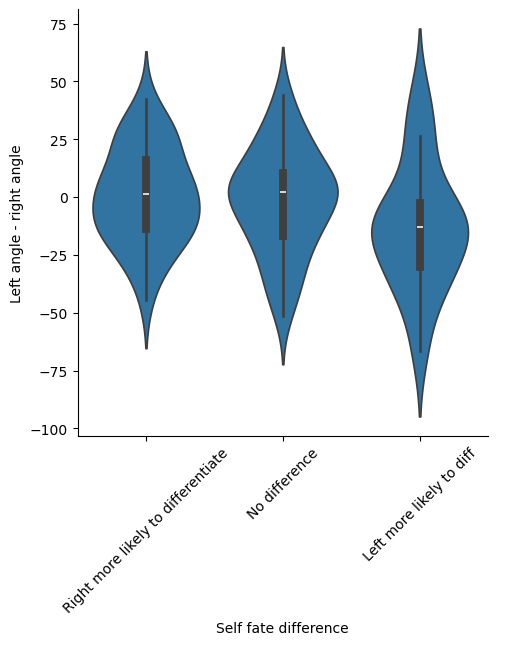

In [260]:
sb.catplot(df,x='Self fate difference',y='Angle difference', kind='violin')
plt.ylabel('Left angle - right angle')
plt.gca().set_xticks([0,1,2],
    labels=['Right more likely to differentiate','No difference','Left more likely to diff'],
                    rotation=45,)

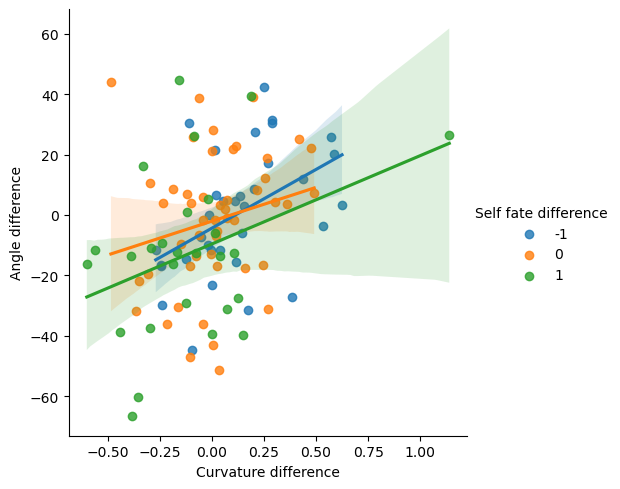

In [263]:
sb.lmplot(df,x='Curvature difference',y='Angle difference',hue='Self fate difference')
# hue='Left daughter fate',

leftID  rightID  Left angle  Right angle  \
Left self fate Right self fate                                             
False          False                25       25          25           25   
               True                 19       19          19           19   
True           False                11       11          11           11   
               True                  2        2           2            2   

                                Angle ratio  Angle difference  Angle sum  \
Left self fate Right self fate                                             
False          False                     25                25         25   
               True                      19                19         19   
True           False                     11                11         11   
               True                       2                 2          2   

                                Left daughter fate  Right daughter fate  \
Left self fate Right self fate                                            
False          False                            21                   19   
               True                             14                    0   
True           False                             0                    7   
               True                              0                    0   

                                Left curvature  Right curvature  \
Left self fate Right self fate                                    
False          False                        25               25   
               True                         19               19   
True           False                        11               11   
               True                          2                2   

                                Curvature ratio  Curvature difference  \
Left self fate Right self fate                                          
False          False                         15                    25   
               True                          11                    19   
True           False                          7                    11   
               True                           2                     2   

                                Left basal area  Right basal area  \
Left self fate Right self fate                                      
False          False                         25                25   
               True                          19                19   
True           False                         11                11   
               True                           2                 2   

                                Basal area ratio  Self fate difference  
Left self fate Right self fate                                          
False          False                          25                    25  
               True                           19                    19  
True           False                          11                    11  
               True                            2                     2

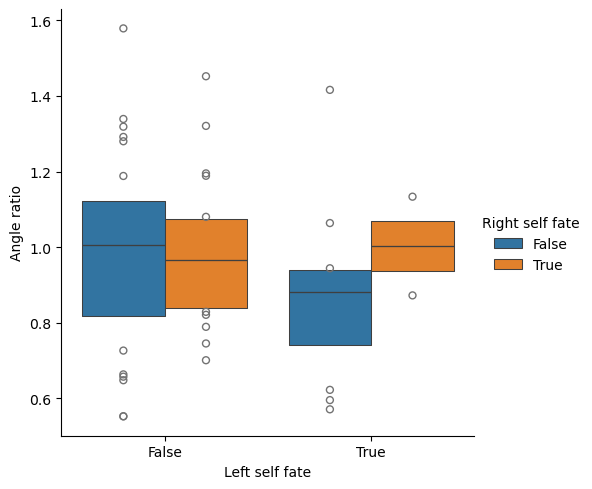

In [78]:
sb.catplot(df,x='Left self fate',hue='Right self fate',y='Angle ratio',dodge=True,kind='boxen')
df.groupby(['Left self fate','Right self fate']).count()

<Axes: xlabel='Basal area ratio', ylabel='Angle ratio'>

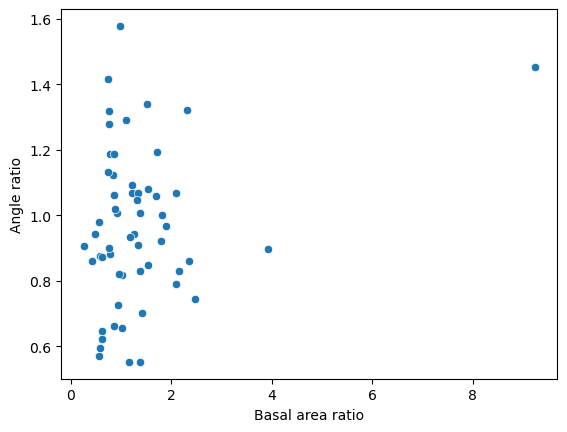

In [77]:
sb.scatterplot(df,x='Basal area ratio',y='Angle ratio')
